# EDA for Comprehensive Banking Database

This notebook performs exploratory data analysis to prepare the dataset for building a personalised financial-recommendation prototype. Objectives:

- Understand data quality, types, and missingness.
- Visualise distributions and relationships useful for recommendation features.
- Perform basic customer segmentation and anomaly detection.
- Propose feature engineering and next steps for modelling and evaluation.


In [1]:
# Standard imports and display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [2]:
# Load dataset with minimal parsing - we'll coerce types intentionally later
DATA_PATH = Path("data") / "Comprehensive_Banking_Database.csv"
df = pd.read_csv(DATA_PATH)
print("rows, cols:", df.shape)
df.head()

rows, cols: (5000, 40)


,Customer ID,First Name,Last Name,Age,Gender,Address,City,Contact Number,Email,Account Type,Account Balance,Date Of Account Opening,Last Transaction Date,TransactionID,Transaction Date,Transaction Type,Transaction Amount,Account Balance After Transaction,Branch ID,Loan ID,Loan Amount,Loan Type,Interest Rate,Loan Term,Approval/Rejection Date,Loan Status,CardID,Card Type,Credit Limit,Credit Card Balance,Minimum Payment Due,Payment Due Date,Last Credit Card Payment Date,Rewards Points,Feedback ID,Feedback Date,Feedback Type,Resolution Status,Resolution Date,Anomaly
0,1,Joshua,Hall,45,Male,Address_1,Fort Worth,19458794854,joshua.hall@kag.com,Current,1313.38,5/26/2006,4/23/2023,1,12/7/2023,Withdrawal,1457.61,2770.99,43,1,32200.06,Mortgage,2.64,36,5/11/2021,Rejected,1,AMEX,1737.88,4524.32,226.22,11/26/2023,3/20/2023,8142,1,10/6/2023,Suggestion,Resolved,1/22/2023,1
1,2,Mark,Taylor,47,Female,Address_2,Louisville,19458794855,mark.taylor@kag.com,Current,5988.46,3/2/2006,1/27/2023,2,4/27/2023,Deposit,1660.99,7649.45,63,2,47743.52,Auto,2.48,36,7/30/2020,Approved,2,MasterCard,1799.36,856.70,42.84,11/5/2023,6/16/2023,4306,2,4/7/2023,Complaint,Resolved,8/27/2023,1
2,3,Joseph,Flores,25,Female,Address_3,Philadelphia,19458794856,joseph.flores@kag.com,Current,8277.88,7/19/2015,1/1/2023,3,4/5/2023,Deposit,839.91,7437.97,82,3,47981.31,Auto,7.84,24,1/17/2021,Closed,3,AMEX,6112.96,3242.36,162.12,1/8/2023,3/20/2023,4842,3,9/7/2023,Praise,Pending,5/11/2023,1
3,4,Kevin,Lee,52,Other,Address_4,Oklahoma City,19458794857,kevin.lee@kag.com,Savings,7487.21,1/30/2008,8/2/2023,4,7/28/2023,Withdrawal,4908.89,12396.10,41,4,4482.80,Personal,7.21,48,2/15/2022,Approved,4,MasterCard,2069.41,4329.17,216.46,9/8/2023,10/15/2023,9463,4,5/28/2023,Complaint,Resolved,7/5/2023,1
4,5,Linda,Johnson,68,Other,Address_5,Phoenix,19458794858,linda.johnson@kag.com,Savings,6993.55,5/25/2021,3/27/2023,5,1/16/2023,Transfer,589.07,6404.48,9,5,1092.33,Mortgage,5.37,12,7/31/2020,Approved,5,Visa,2765.30,25.72,1.29,3/4/2023,7/27/2023,2209,5,2/12/2023,Complaint,Resolved,11/21/2023,1


In [3]:
# Data cleaning and type conversion (safe, with try/except as requested in repo instructions)
df_clean = df.copy()

# Helper to coerce dates where possible
date_cols = [
    "Date Of Account Opening",
    "Last Transaction Date",
    "Transaction Date",
    "Approval/Rejection Date",
    "Payment Due Date",
    "Last Credit Card Payment Date",
    "Feedback Date",
    "Resolution Date",
]
for c in date_cols:
    if c in df_clean.columns:
        try:
            df_clean[c] = pd.to_datetime(df_clean[c], errors="coerce")
        except Exception as e:
            print(f"Failed to parse {c}:", e)

# Coerce numeric-ish columns to numeric, warn on failures
num_cols = [
    "Account Balance",
    "Transaction Amount",
    "Account Balance After Transaction",
    "Loan Amount",
    "Interest Rate",
    "Loan Term",
    "Credit Limit",
    "Credit Card Balance",
    "Minimum Payment Due",
    "Rewards Points",
]
for c in num_cols:
    if c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

# Flag suspicious values
df_clean["negative_balance"] = False
if "Account Balance" in df_clean.columns:
    df_clean.loc[df_clean["Account Balance"] < 0, "negative_balance"] = True

# Ensure categorical columns are category dtype for efficient plotting
cat_cols = [
    "Gender",
    "Account Type",
    "Transaction Type",
    "Card Type",
    "Loan Type",
    "Feedback Type",
    "Resolution Status",
    "City",
]
for c in cat_cols:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].astype("category")

print("After cleaning:")
display(df_clean.dtypes.value_counts())
display(df_clean.isna().sum().sort_values(ascending=False).head(20))

After cleaning:


int64             11
datetime64[ns]     8
float64            8
object             5
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
bool               1
Name: count, dtype: int64

Customer ID                          0
First Name                           0
Last Name                            0
Age                                  0
Gender                               0
Address                              0
City                                 0
Contact Number                       0
Email                                0
Account Type                         0
Account Balance                      0
Date Of Account Opening              0
Last Transaction Date                0
TransactionID                        0
Transaction Date                     0
Transaction Type                     0
Transaction Amount                   0
Account Balance After Transaction    0
Branch ID                            0
Loan ID                              0
dtype: int64

In [4]:
# Missing value exploration and simple imputation suggestions
missing = df_clean.isna().sum().loc[lambda x: x > 0].sort_values(ascending=False)
missing

# Example: if Transaction Amount is missing we might set 0 for account-level summary, but preserve as NaN for transaction models
if "Transaction Amount" in df_clean.columns:
    print("Transaction Amount missing %:", df_clean["Transaction Amount"].isna().mean())

# Keep imputation minimal in EDA: show rows with many nulls
df_clean["null_count"] = df_clean.isna().sum(axis=1)
display(df_clean.sort_values("null_count", ascending=False).head(5))

Transaction Amount missing %: 0.0


,Customer ID,First Name,Last Name,Age,Gender,Address,City,Contact Number,Email,Account Type,Account Balance,Date Of Account Opening,Last Transaction Date,TransactionID,Transaction Date,Transaction Type,Transaction Amount,Account Balance After Transaction,Branch ID,Loan ID,Loan Amount,Loan Type,Interest Rate,Loan Term,Approval/Rejection Date,Loan Status,CardID,Card Type,Credit Limit,Credit Card Balance,Minimum Payment Due,Payment Due Date,Last Credit Card Payment Date,Rewards Points,Feedback ID,Feedback Date,Feedback Type,Resolution Status,Resolution Date,Anomaly,negative_balance,null_count
4999,5000,Daniel,Martinez,35,Male,Address_5000,El Paso,19458799853,daniel.martinez@kag.com,Current,7022.99,2006-07-11,2023-01-04,5000,2023-08-28,Withdrawal,281.35,6741.64,85,5000,16784.32,Auto,4.01,12,2021-09-23,Rejected,5000,AMEX,2015.38,3078.08,153.90,2023-05-30,2023-06-03,1816,5000,2023-09-06,Suggestion,Resolved,2023-05-23,1,False,0
0,1,Joshua,Hall,45,Male,Address_1,Fort Worth,19458794854,joshua.hall@kag.com,Current,1313.38,2006-05-26,2023-04-23,1,2023-12-07,Withdrawal,1457.61,2770.99,43,1,32200.06,Mortgage,2.64,36,2021-05-11,Rejected,1,AMEX,1737.88,4524.32,226.22,2023-11-26,2023-03-20,8142,1,2023-10-06,Suggestion,Resolved,2023-01-22,1,False,0
1,2,Mark,Taylor,47,Female,Address_2,Louisville,19458794855,mark.taylor@kag.com,Current,5988.46,2006-03-02,2023-01-27,2,2023-04-27,Deposit,1660.99,7649.45,63,2,47743.52,Auto,2.48,36,2020-07-30,Approved,2,MasterCard,1799.36,856.70,42.84,2023-11-05,2023-06-16,4306,2,2023-04-07,Complaint,Resolved,2023-08-27,1,False,0
2,3,Joseph,Flores,25,Female,Address_3,Philadelphia,19458794856,joseph.flores@kag.com,Current,8277.88,2015-07-19,2023-01-01,3,2023-04-05,Deposit,839.91,7437.97,82,3,47981.31,Auto,7.84,24,2021-01-17,Closed,3,AMEX,6112.96,3242.36,162.12,2023-01-08,2023-03-20,4842,3,2023-09-07,Praise,Pending,2023-05-11,1,False,0
3,4,Kevin,Lee,52,Other,Address_4,Oklahoma City,19458794857,kevin.lee@kag.com,Savings,7487.21,2008-01-30,2023-08-02,4,2023-07-28,Withdrawal,4908.89,12396.10,41,4,4482.80,Personal,7.21,48,2022-02-15,Approved,4,MasterCard,2069.41,4329.17,216.46,2023-09-08,2023-10-15,9463,4,2023-05-28,Complaint,Resolved,2023-07-05,1,False,0


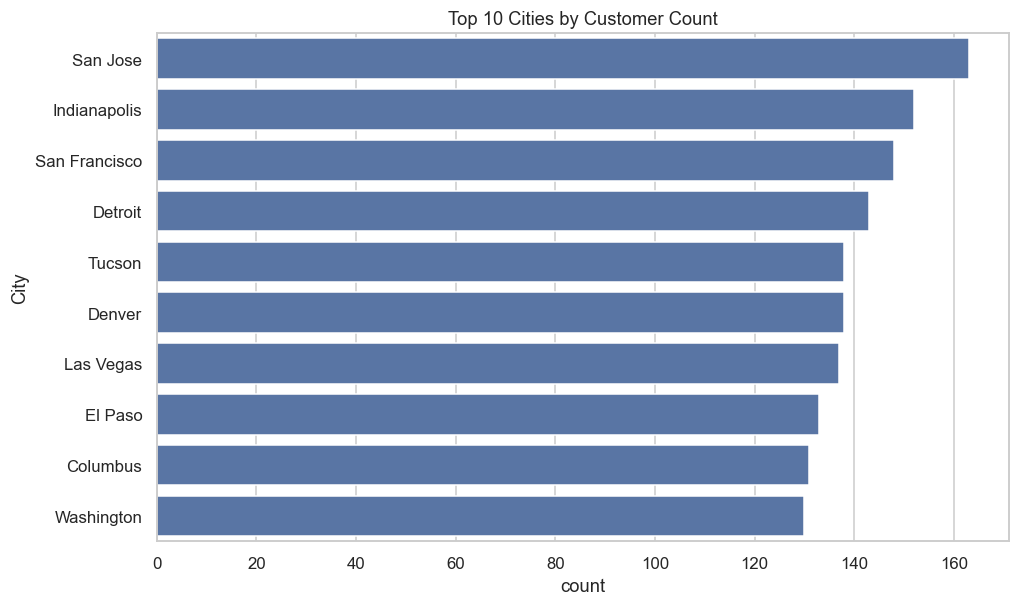

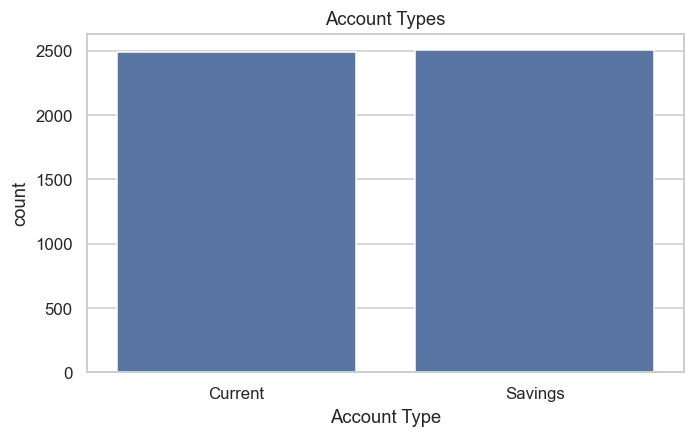

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(
    y="City", data=df_clean, order=df_clean["City"].value_counts().nlargest(10).index
)
plt.title("Top 10 Cities by Customer Count")
plt.show()

plt.figure(figsize=(7, 4))
sns.countplot(x="Account Type", data=df_clean)
plt.title("Account Types")
plt.show()

In [ ]:
# 3) City segmentation: top cities average account balance and median age
temp_df = df_clean.copy()
# remove cities without account balance  and median age
temp_df = temp_df[temp_df["Account Balance"].notna() & temp_df["Age"].notna()]

if "City" in temp_df.columns and "Account Balance" in temp_df.columns:
    city_stats = (
        temp_df.groupby("City", observed=True)
        .agg({"Account Balance": "mean", "Age": "median", "Customer ID": "count"})
        .rename(columns={"Customer ID": "count"})
    )
    # Use top 10 cities by customer count
    top_cities = city_stats.sort_values("count", ascending=False).head(10).reset_index()

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Mean Account Balance (horizontal bars) with value annotations
    sns.barplot(
        x="Account Balance",
        y="City",
        data=top_cities,
        ax=ax[0],
        palette="Blues_d",
        order=top_cities["City"],
    )
    ax[0].set_title("Top 10 cities: mean Account Balance")
    ax[0].set_xlabel("Mean Account Balance")
    for p in ax[0].patches:
        width = p.get_width()
        ax[0].annotate(
            f"{width:,.0f}",
            (width, p.get_y() + p.get_height() / 2),
            xytext=(5, 0),
            textcoords="offset points",
            va="center",
        )

    # Median Age (horizontal bars) with value annotations
    sns.barplot(
        x="Age",
        y="City",
        data=top_cities,
        ax=ax[1],
        palette="Greens_d",
        order=top_cities["City"],
    )
    ax[1].set_title("Top 10 cities: median Age")
    plt.tight_layout()
    plt.show()
else:
    print("City or Account Balance missing for city segmentation")

temp_df

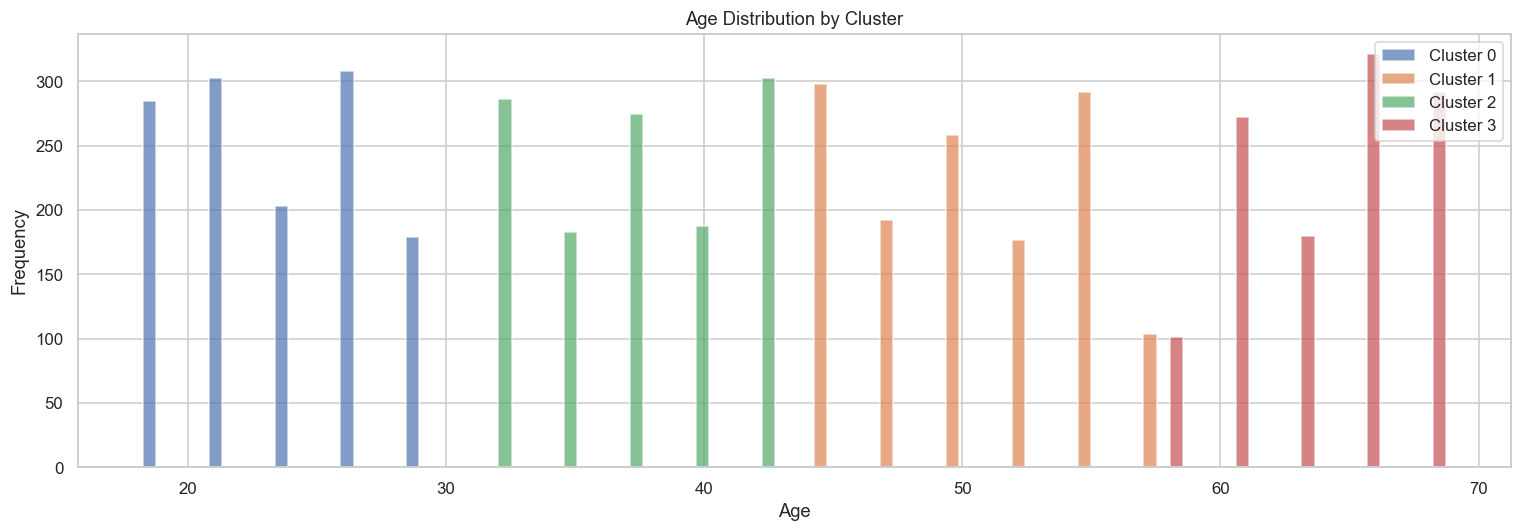


Age Cluster Statistics:


,Mean Age,Median Age,Min Age,Max Age,Customer Count
age_cluster,,,,,
0,23.978873,24.0,18,30,1278
2,37.090688,37.0,31,43,1235
1,50.499621,50.0,44,57,1321
3,63.625214,64.0,58,69,1166


In [7]:
# K-Means clustering on Age to explain distribution patterns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

if "Age" in df_clean.columns:
    # Prepare data for clustering (remove NaN)
    age_data = df_clean[["Age"]].dropna()

    # Determine optimal number of clusters using elbow method
    inertias = []
    K_range = range(2, 8)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(age_data)
        inertias.append(kmeans.inertia_)

    # Apply K-Means with optimal k (let's use k=4 as example)
    optimal_k = 4
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    age_data_copy = age_data.copy()
    age_data_copy["age_cluster"] = kmeans.fit_predict(age_data)

    # Visualize clusters
    fig, axes = plt.subplots(1, 1, figsize=(14, 5))

    # Distribution by cluster
    axes.hist(
        [
            age_data_copy[age_data_copy["age_cluster"] == i]["Age"]
            for i in range(optimal_k)
        ],
        bins=20,
        label=[f"Cluster {i}" for i in range(optimal_k)],
        alpha=0.7,
        stacked=False,
    )
    axes.set_xlabel("Age")
    axes.set_ylabel("Frequency")
    axes.set_title("Age Distribution by Cluster")
    axes.legend()

    plt.tight_layout()
    plt.show()

    # Cluster statistics
    cluster_stats = age_data_copy.groupby("age_cluster")["Age"].agg(
        ["mean", "median", "min", "max", "count"]
    )
    cluster_stats.columns = [
        "Mean Age",
        "Median Age",
        "Min Age",
        "Max Age",
        "Customer Count",
    ]
    print("\nAge Cluster Statistics:")
    display(cluster_stats.sort_values("Mean Age"))

    # Merge cluster labels back to main dataframe for further analysis
    df_clean = df_clean.merge(
        age_data_copy[["age_cluster"]], left_index=True, right_index=True, how="left"
    )
else:
    print("Age column not available for clustering")

Available Account Types: ['Current', 'Savings']
Categories (2, object): ['Current', 'Savings']


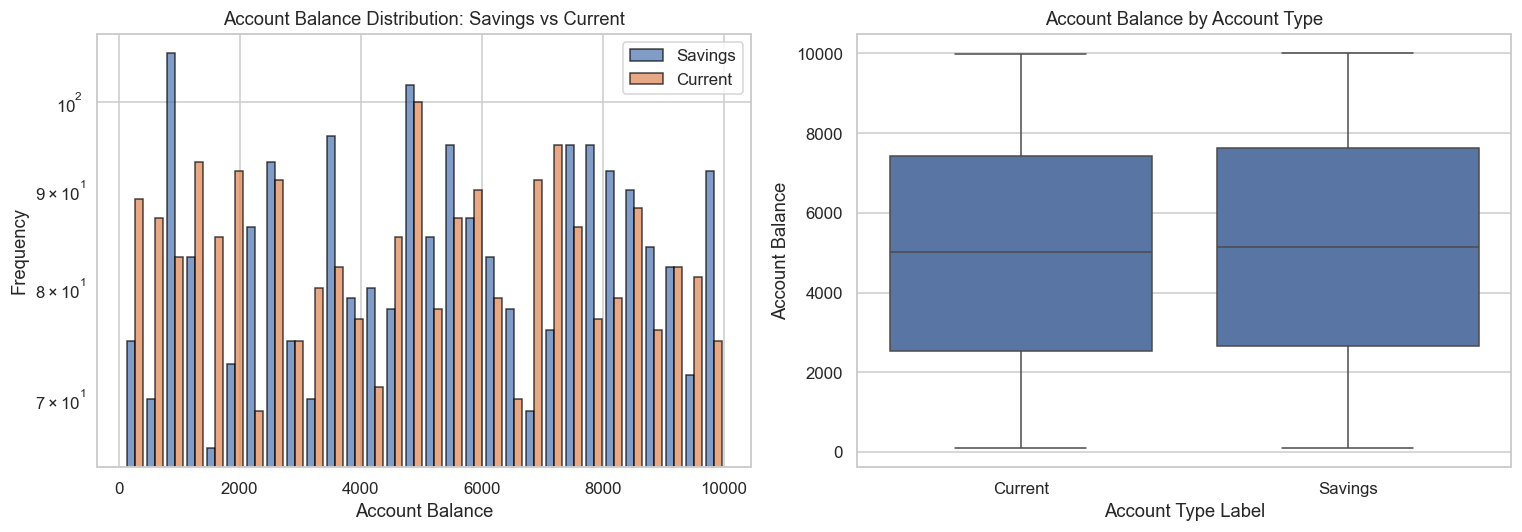

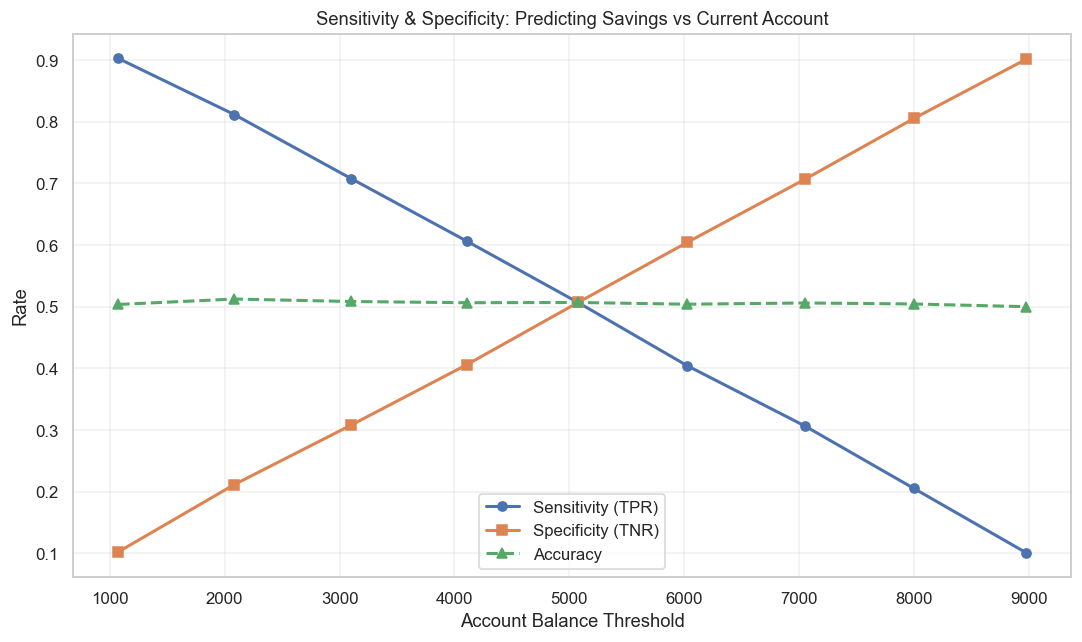


Sensitivity & Specificity Analysis Results:


,Threshold,Sensitivity,Specificity,Accuracy
0,1074.591,0.903,0.103,0.504
1,2083.638,0.812,0.212,0.513
2,3099.296,0.708,0.308,0.509
3,4108.828,0.606,0.406,0.507
4,5075.500,0.507,0.507,0.507
5,6025.954,0.404,0.604,0.504
6,7049.668,0.307,0.707,0.506
7,7999.028,0.205,0.805,0.505
8,8974.701,0.101,0.901,0.500


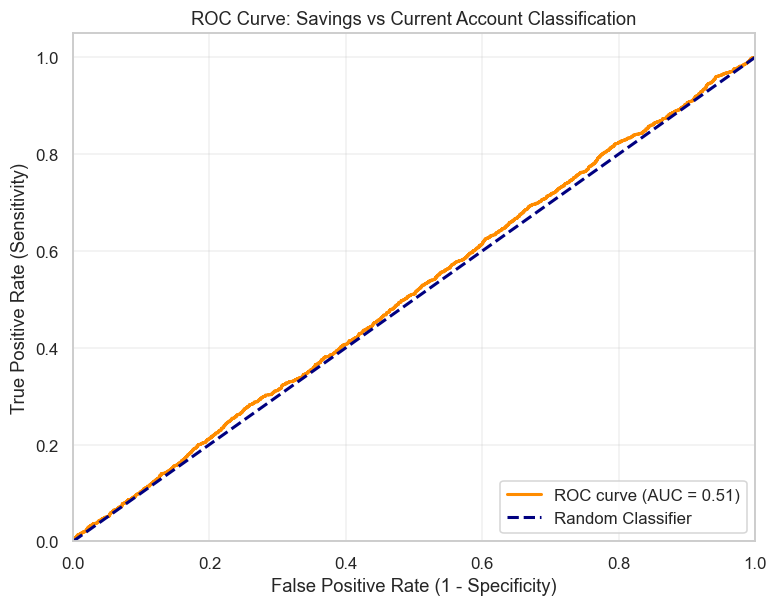


Summary Statistics:
Total Samples: 5000
Savings Accounts: 2507 (50.1%)
Current Accounts: 2493 (49.9%)
ROC AUC Score: 0.512


In [8]:
# Sensitivity and Specificity Analysis: Savings vs Current Account
# Using Account Balance threshold to predict account type

if "Account Type" in df_clean.columns and "Account Balance" in df_clean.columns:
    # Filter for Savings and Current accounts only
    account_types = df_clean["Account Type"].unique()
    print("Available Account Types:", account_types)

    # Flexible matching for account type names
    savings_mask = (
        df_clean["Account Type"]
        .astype(str)
        .str.contains("Saving", case=False, na=False)
    )
    current_mask = (
        df_clean["Account Type"]
        .astype(str)
        .str.contains("Current", case=False, na=False)
    )

    df_binary = df_clean[savings_mask | current_mask].copy()
    df_binary = df_binary.dropna(subset=["Account Balance"])

    if len(df_binary) > 0:
        # Create binary label: 1 for Savings, 0 for Current
        df_binary["is_savings"] = savings_mask[savings_mask | current_mask].astype(int)

        # Visualize distribution by account type
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Distribution comparison
        savings_balance = df_binary[df_binary["is_savings"] == 1]["Account Balance"]
        current_balance = df_binary[df_binary["is_savings"] == 0]["Account Balance"]

        axes[0].hist(
            [savings_balance, current_balance],
            bins=30,
            label=["Savings", "Current"],
            alpha=0.7,
            edgecolor="black",
        )
        axes[0].set_xlabel("Account Balance")
        axes[0].set_ylabel("Frequency")
        axes[0].set_title("Account Balance Distribution: Savings vs Current")
        axes[0].legend()
        axes[0].set_yscale("log")

        # Box plot comparison
        df_binary["Account Type Label"] = df_binary["is_savings"].map(
            {1: "Savings", 0: "Current"}
        )
        sns.boxplot(
            x="Account Type Label", y="Account Balance", data=df_binary, ax=axes[1]
        )
        axes[1].set_title("Account Balance by Account Type")
        axes[1].set_ylabel("Account Balance")

        plt.tight_layout()
        plt.show()

        # Calculate sensitivity and specificity across different thresholds
        from sklearn.metrics import confusion_matrix, roc_curve, auc

        # Use account balance as predictor
        thresholds = np.percentile(df_binary["Account Balance"], np.arange(10, 100, 10))

        results = []
        for threshold in thresholds:
            # Predict: if balance > threshold, predict Savings (1), else Current (0)
            y_pred = (df_binary["Account Balance"] > threshold).astype(int)
            y_true = df_binary["is_savings"]

            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # True Positive Rate
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # True Negative Rate
            accuracy = (tp + tn) / (tp + tn + fp + fn)

            results.append(
                {
                    "Threshold": threshold,
                    "Sensitivity": sensitivity,
                    "Specificity": specificity,
                    "Accuracy": accuracy,
                    "TP": tp,
                    "TN": tn,
                    "FP": fp,
                    "FN": fn,
                }
            )

        results_df = pd.DataFrame(results)

        # Plot Sensitivity and Specificity curves
        plt.figure(figsize=(10, 6))
        plt.plot(
            results_df["Threshold"],
            results_df["Sensitivity"],
            marker="o",
            label="Sensitivity (TPR)",
            linewidth=2,
        )
        plt.plot(
            results_df["Threshold"],
            results_df["Specificity"],
            marker="s",
            label="Specificity (TNR)",
            linewidth=2,
        )
        plt.plot(
            results_df["Threshold"],
            results_df["Accuracy"],
            marker="^",
            label="Accuracy",
            linewidth=2,
            linestyle="--",
        )
        plt.xlabel("Account Balance Threshold")
        plt.ylabel("Rate")
        plt.title("Sensitivity & Specificity: Predicting Savings vs Current Account")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Display results table
        print("\nSensitivity & Specificity Analysis Results:")
        display(
            results_df[["Threshold", "Sensitivity", "Specificity", "Accuracy"]].round(3)
        )

        # ROC Curve
        fpr, tpr, roc_thresholds = roc_curve(
            df_binary["is_savings"], df_binary["Account Balance"]
        )
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(
            fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
        )
        plt.plot(
            [0, 1],
            [0, 1],
            color="navy",
            lw=2,
            linestyle="--",
            label="Random Classifier",
        )
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate (1 - Specificity)")
        plt.ylabel("True Positive Rate (Sensitivity)")
        plt.title("ROC Curve: Savings vs Current Account Classification")
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.show()

        print(f"\nSummary Statistics:")
        print(f"Total Samples: {len(df_binary)}")
        print(
            f"Savings Accounts: {savings_mask[savings_mask | current_mask].sum()} ({savings_mask[savings_mask | current_mask].sum()/len(df_binary)*100:.1f}%)"
        )
        print(
            f"Current Accounts: {current_mask[savings_mask | current_mask].sum()} ({current_mask[savings_mask | current_mask].sum()/len(df_binary)*100:.1f}%)"
        )
        print(f"ROC AUC Score: {roc_auc:.3f}")

    else:
        print("No Savings or Current accounts found in the dataset")
else:
    print(
        "Account Type or Account Balance columns not available for sensitivity/specificity analysis"
    )